In [1]:
# Cell 1
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# Set this before importing torch or transformers
os.environ["CUDA_VISIBLE_DEVICES"] = "3,4,5,6,7"

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

print("Libraries imported and GPUs set.")

/data/literature/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/literature/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Libraries imported and GPUs set.


In [2]:
# 📂 Dataset Paths
DATASET_DIR = Path("/home/literature/hindwi-scraper/output")
POETS_JSON = DATASET_DIR / "poets.json"

In [3]:
# 📥 Load poets.json
with open(POETS_JSON, encoding='utf-8') as f:
    poets = json.load(f)

In [4]:
# 🔄 poet_slug → poet metadata
poet_map = {poet['poet_slug']: poet for poet in poets}

In [5]:

poets_dir = DATASET_DIR / "poets"  # adjust if needed

summary = []

print("Counting poems ending with -devnagri.txt ...")

for poet_dir in tqdm([p for p in poets_dir.iterdir() if p.is_dir()]):
    poet_name = poet_dir.name
    kavita_dir = poet_dir / "kavita"

    if not kavita_dir.is_dir():
        continue

    # collect all files that end with -devnagri.txt
    devnagri_poems = [
        f for f in kavita_dir.iterdir()
        if f.is_file() and f.name.endswith("-devnagri.txt")
    ]

    summary.append({
        "poet_name": poet_name,
        "devanagari_count": len(devnagri_poems)
    })

# 📊 Per-poet DataFrame
df_summary = pd.DataFrame(summary).sort_values("devanagari_count", ascending=False)

print("\n=== Top 20 poets by Devanagari poem count ===")
print(df_summary.head(20))

# Save if needed
# df_summary.to_csv("dataset/poet_summary_filebased.csv", index=False, encoding="utf-8")


Counting poems ending with -devnagri.txt ...


100%|██████████| 2382/2382 [00:00<00:00, 9692.85it/s]


=== Top 20 poets by Devanagari poem count ===
                    poet_name  devanagari_count
1229              mona-gulati               113
339         pankaj-chaturvedi                87
1353      vijay-bahadur-singh                84
1492  krishna-murari-pahariya                81
1843             savita-singh                78
685               hari-mridul                75
178                     laltu                75
847              naveen-sagar                74
992       neelesh-raghuvanshi                71
1603      maithilisharan-gupt                70
1605  sheomangal-siddhantakar                70
1142                   malyaj                69
1746        sanjay-chaturvedi                67
507                    shubha                65
1021                 udbhrant                65
269              chandreshwar                62
694            krishna-kalpit                62
1181          manglesh-dabral                61
971             narendra-jain            

In [ ]:

poets_dir = DATASET_DIR / "poets"
min_poems = 50
# This creates df_filtered with poet_name and poem columns

# 🔢 Count poems ending with "-devnagri.txt" for each poet
poet_counts = {}
for poet_dir in tqdm(list(poets_dir.iterdir()), desc="Counting poems"):
    if poet_dir.is_dir():
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            count = sum(1 for f in kavita_dir.glob("*-devnagri.txt"))
            if count > 0:
                poet_counts[poet_dir.name] = count

# 📊 Convert to DataFrame
poem_counts = pd.DataFrame(list(poet_counts.items()), columns=["poet_name", "devanagari_count"])

# 🎯 Filter poets with at least min_poems
poets_to_keep = set(poem_counts.loc[poem_counts["devanagari_count"] >= min_poems, "poet_name"])

print(f"Total poets with >= {min_poems} poems: {len(poets_to_keep)}")

# 📚 Build dataset (poet_name → poem text)
all_poems = []
for poet_dir in tqdm(list(poets_dir.iterdir()), desc="Loading poems"):
    if poet_dir.is_dir() and poet_dir.name in poets_to_keep:
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            for poem_file in kavita_dir.glob("*-devnagri.txt"):
                try:
                    poem_text = poem_file.read_text(encoding='utf-8').strip()
                    if poem_text:
                        all_poems.append({
                            "poet_name": poet_dir.name,
                            "poem": poem_text
                        })
                except Exception as e:
                    print(f"Error reading {poem_file}: {e}")

# 📑 Final DataFrame
df_filtered = pd.DataFrame(all_poems)

print(f"\nFinal dataset size: {len(df_filtered)} poems")
print(f"Unique poets: {df_filtered['poet_name'].nunique()}")
print("\nSample:")
print(df_filtered.head())


Counting poems: 100%|██████████| 2382/2382 [00:00<00:00, 20888.47it/s]


Total poets with >= 50 poems: 42


Loading poems: 100%|██████████| 2382/2382 [00:00<00:00, 13268.16it/s]


Final dataset size: 2451 poems
Unique poets: 41

Sample:
                   poet_name  \
0  acharya-ramchandra-shukla   
1  acharya-ramchandra-shukla   
2  acharya-ramchandra-shukla   
3  acharya-ramchandra-shukla   
4  acharya-ramchandra-shukla   

                                                poem  
0  भोले भाले देश भाइयों से जरा।\nभिन्न लगें, यह भ...  
1  भूलि गयो सब पूजा पाठ विचार\nकेवल उनकी ध्यान भय...  
2  तन में भरम रमायो त्यागी राज,\nसहन कठिन दुख कीन...  
3  पहले पहल पुकारा था जिसने जहाँ\nजिन नामों से जन...  
4  यद्यपि मैं हूँ एक अकेला, बैरी की सेना भारी।\nप...  


In [7]:
# Cell 15 - Update GPU configuration to use only GPU 3
import os
import torch

# Set GPU 3 only
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# Verify GPU setup
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available - will use CPU")

# Model configuration
MODEL_NAME = "google/muril-large-cased"
print(f"\nUsing model: {MODEL_NAME}")
print(f"Final dataset: {len(df_filtered)} poems from {df_filtered['poet_name'].nunique()} poets")

CUDA available: True
Number of GPUs: 1
Current GPU: 0
GPU name: NVIDIA RTX A6000

Using model: google/muril-large-cased
Final dataset: 2451 poems from 41 poets


In [8]:
# Cell 16 - Data preparation and label encoding
from sklearn.preprocessing import LabelEncoder

# Create label encoder for poet names
label_encoder = LabelEncoder()
df_filtered['poet_label'] = label_encoder.fit_transform(df_filtered['poet_name'])

# Get number of unique poets (classes)
num_classes = len(label_encoder.classes_)
print(f"Number of classes (poets): {num_classes}")
print(f"Classes: {list(label_encoder.classes_[:10])}...")  # Show first 10

# Check class distribution
class_counts = df_filtered['poet_name'].value_counts()
print(f"\nClass distribution (top 10):")
print(class_counts.head(10))

# Verify label encoding
print(f"\nSample label mapping:")
for i in range(min(5, len(label_encoder.classes_))):
    poet_name = label_encoder.classes_[i]
    label = label_encoder.transform([poet_name])[0]
    print(f"{poet_name} -> {label}")

print(f"\nDataset shape: {df_filtered.shape}")
print(f"Columns: {df_filtered.columns.tolist()}")

# Save label encoder for later use
import pickle
with open('poet_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved as 'poet_label_encoder.pkl'")

Number of classes (poets): 41
Classes: ['acharya-ramchandra-shukla', 'agyeya', 'baby-shaw', 'chandrakant-devtale-1', 'chandreshwar', 'dafairoon', 'dilip-purushottam-chitre', 'hare-prakash-upadhyay', 'hari-mridul', 'jagdish-chaturvedi']...

Class distribution (top 10):
poet_name
mona-gulati                108
vijay-bahadur-singh         84
pankaj-chaturvedi           82
krishna-murari-pahariya     81
savita-singh                76
naveen-sagar                74
laltu                       72
sheomangal-siddhantakar     70
malyaj                      68
neelesh-raghuvanshi         68
Name: count, dtype: int64

Sample label mapping:
acharya-ramchandra-shukla -> 0
agyeya -> 1
baby-shaw -> 2
chandrakant-devtale-1 -> 3
chandreshwar -> 4

Dataset shape: (2451, 3)
Columns: ['poet_name', 'poem', 'poet_label']
✅ Label encoder saved as 'poet_label_encoder.pkl'


In [9]:
# Cell 17 - Train/Validation/Test Split (80-10-10)
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp (which will become 10% val + 10% test)
X = df_filtered['poem'].values
y = df_filtered['poet_label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for val+test
    random_state=42, 
    stratify=y  # Maintain class distribution
)

# Second split: Split the 20% temp into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # Split the 20% equally: 10% val, 10% test
    random_state=42,
    stratify=y_temp
)

# Print split statistics
print("📊 Dataset Split Statistics:")
print(f"Total samples: {len(X)}")
print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in each split
print(f"\n🎯 Class distribution check:")
print(f"Train classes: {len(np.unique(y_train))}")
print(f"Val classes: {len(np.unique(y_val))}")
print(f"Test classes: {len(np.unique(y_test))}")

# Show sample distribution for top poets
train_df = pd.DataFrame({'poet_label': y_train})
val_df = pd.DataFrame({'poet_label': y_val})
test_df = pd.DataFrame({'poet_label': y_test})

print(f"\n📈 Sample distribution for top 5 poets:")
for i in range(min(5, num_classes)):
    poet_name = label_encoder.classes_[i]
    poet_label = i
    train_count = (y_train == poet_label).sum()
    val_count = (y_val == poet_label).sum()
    test_count = (y_test == poet_label).sum()
    total_count = train_count + val_count + test_count
    
    print(f"{poet_name}: Train={train_count}, Val={val_count}, Test={test_count}, Total={total_count}")

print("\n✅ Data split completed successfully!")

📊 Dataset Split Statistics:
Total samples: 2451
Train: 1960 (80.0%)
Validation: 245 (10.0%)
Test: 246 (10.0%)

🎯 Class distribution check:
Train classes: 41
Val classes: 41
Test classes: 41

📈 Sample distribution for top 5 poets:
acharya-ramchandra-shukla: Train=46, Val=6, Test=6, Total=58
agyeya: Train=39, Val=5, Test=5, Total=49
baby-shaw: Train=41, Val=5, Test=5, Total=51
chandrakant-devtale-1: Train=40, Val=5, Test=5, Total=50
chandreshwar: Train=50, Val=6, Test=6, Total=62

✅ Data split completed successfully!


In [10]:
# Cell 18 - Tokenizer Setup and Text Preprocessing
from transformers import AutoTokenizer

# Load muRIL tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Set maximum sequence length
MAX_LENGTH = 512  # muRIL can handle up to 512 tokens
print(f"Max sequence length: {MAX_LENGTH}")

# Function to preprocess and tokenize text
def preprocess_function(examples):
    """Tokenize the poems for model input"""
    return tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

# Check text length statistics
text_lengths = [len(text.split()) for text in X_train]
print(f"\n📏 Text Length Statistics (words):")
print(f"Mean: {np.mean(text_lengths):.1f}")
print(f"Median: {np.median(text_lengths):.1f}")
print(f"Max: {max(text_lengths)}")
print(f"Min: {min(text_lengths)}")

# Check how many texts will be truncated
long_texts = sum(1 for length in text_lengths if length > MAX_LENGTH * 0.75)  # Rough estimate
print(f"Texts likely to be truncated: {long_texts}/{len(text_lengths)} ({long_texts/len(text_lengths)*100:.1f}%)")

# Test tokenization on a sample
sample_poem = X_train[0]
print(f"\n🔤 Sample tokenization:")
print(f"Original text (first 100 chars): {sample_poem[:100]}...")

tokens = tokenizer(
    sample_poem,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

print(f"Tokenized length: {tokens['input_ids'].shape}")
print(f"Attention mask shape: {tokens['attention_mask'].shape}")

# Decode to verify
decoded = tokenizer.decode(tokens['input_ids'][0][:50])  # First 50 tokens
print(f"Decoded (first 50 tokens): {decoded}")

print("\n✅ Tokenizer setup completed!")

Loading tokenizer: google/muril-large-cased
Max sequence length: 512

📏 Text Length Statistics (words):
Mean: 120.3
Median: 86.0
Max: 1826
Min: 4
Texts likely to be truncated: 75/1960 (3.8%)

🔤 Sample tokenization:
Original text (first 100 chars): नहीं रहे दिन रंग-रूप-रस पान के
बदल गए संबंध समय से प्राण के
बीत गई सपनों वाली अब रात है
जलते सत्यों ...
Tokenized length: torch.Size([1, 512])
Attention mask shape: torch.Size([1, 512])
Decoded (first 50 tokens): [CLS] नहीं रहे दिन रंग - रूप - रस पान के बदल गए संबंध समय से प्राण के बीत गई सपनों वाली अब रात है जलते सत्यों का यह उगा प्रभात है मलयानिल के सुरभि झकोरे चुक गए दिशा - दिशा

✅ Tokenizer setup completed!


In [11]:
# Cell 19 - Create HuggingFace Datasets
from datasets import Dataset

# Create datasets from our splits
train_dataset = Dataset.from_dict({
    'poem': X_train.tolist(),
    'labels': y_train.tolist()
})

val_dataset = Dataset.from_dict({
    'poem': X_val.tolist(), 
    'labels': y_val.tolist()
})

test_dataset = Dataset.from_dict({
    'poem': X_test.tolist(),
    'labels': y_test.tolist()
})

print("📚 Dataset creation:")
print(f"Train dataset: {train_dataset}")
print(f"Validation dataset: {val_dataset}")
print(f"Test dataset: {test_dataset}")

# Apply tokenization to all datasets
print("\n🔤 Tokenizing datasets...")

# Tokenize training data
train_dataset = train_dataset.map(
    lambda examples: tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ),
    batched=True,
    desc="Tokenizing train data"
)

# Tokenize validation data
val_dataset = val_dataset.map(
    lambda examples: tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ),
    batched=True,
    desc="Tokenizing validation data"
)

# Tokenize test data
test_dataset = test_dataset.map(
    lambda examples: tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ),
    batched=True,
    desc="Tokenizing test data"
)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("\n✅ Datasets tokenized and formatted!")
print(f"Train dataset features: {train_dataset.features}")
print(f"Sample from train dataset: {train_dataset[0]['input_ids'].shape}")

# Quick check
print(f"\n🔍 Quick verification:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")

📚 Dataset creation:
Train dataset: Dataset({
    features: ['poem', 'labels'],
    num_rows: 1960
})
Validation dataset: Dataset({
    features: ['poem', 'labels'],
    num_rows: 245
})
Test dataset: Dataset({
    features: ['poem', 'labels'],
    num_rows: 246
})

🔤 Tokenizing datasets...


Tokenizing test data: 100%|██████████| 246/246 [00:00<00:00, 4197.27 examples/s]


✅ Datasets tokenized and formatted!
Train dataset features: {'poem': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Sample from train dataset: torch.Size([512])

🔍 Quick verification:
Train samples: 1960
Val samples: 245
Test samples: 246
Number of classes: 41


In [12]:
# Cell 20 - Load and Configure muRIL Model
from transformers import AutoModelForSequenceClassification
import torch

# Load muRIL model for sequence classification
print(f"🤖 Loading model: {MODEL_NAME}")
print(f"Number of classes: {num_classes}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label={i: label_encoder.classes_[i] for i in range(num_classes)},
    label2id={label_encoder.classes_[i]: i for i in range(num_classes)}
)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded on device: {device}")
print(f"Model type: {type(model).__name__}")

# Print model configuration
print(f"\n📋 Model Configuration:")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Number of attention heads: {model.config.num_attention_heads}")
print(f"Number of layers: {model.config.num_hidden_layers}")
print(f"Max position embeddings: {model.config.max_position_embeddings}")
print(f"Vocab size: {model.config.vocab_size}")

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🔢 Model Parameters:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Check model output for a sample
print(f"\n🧪 Testing model with sample input...")
sample_input = {
    'input_ids': train_dataset[0]['input_ids'].unsqueeze(0).to(device),
    'attention_mask': train_dataset[0]['attention_mask'].unsqueeze(0).to(device)
}

with torch.no_grad():
    outputs = model(**sample_input)
    logits = outputs.logits
    predictions = torch.softmax(logits, dim=-1)
    
print(f"Sample input shape: {sample_input['input_ids'].shape}")
print(f"Model output shape: {logits.shape}")
print(f"Predicted class: {torch.argmax(predictions, dim=-1).item()}")
print(f"Actual class: {train_dataset[0]['labels'].item()}")

print("\n✅ Model loaded and configured successfully!")

🤖 Loading model: google/muril-large-cased
Number of classes: 41


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-large-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on device: cuda
Model type: BertForSequenceClassification

📋 Model Configuration:
Hidden size: 1024
Number of attention heads: 16
Number of layers: 24
Max position embeddings: 512
Vocab size: 197285

🔢 Model Parameters:
Total parameters: 505,949,225
Trainable parameters: 505,949,225

🧪 Testing model with sample input...
Sample input shape: torch.Size([1, 512])
Model output shape: torch.Size([1, 41])
Predicted class: 22
Actual class: 15

✅ Model loaded and configured successfully!


In [13]:
# Cell 21 - Fixed Training Configuration and Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import EarlyStoppingCallback
import numpy as np

# Define compute metrics function
def compute_metrics(eval_pred):
    """Compute metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training arguments (FIXED - removed invalid parameters)
from transformers import TrainingArguments

# Create output directory
output_dir = "./muril_poet_classifier"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=50,              # Reduced epochs to prevent overfitting
    per_device_train_batch_size=8,   # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    warmup_steps=300,                # Reduced warmup steps
    weight_decay=0.1,                # Increased weight decay for regularization
    logging_dir='./logs',            # Directory for storing logs
    logging_steps=50,                # Log every 50 steps
    eval_strategy="steps",     # Evaluate during training
    eval_steps=200,                  # Evaluate every 200 steps
    save_strategy="steps",           # Save checkpoints
    save_steps=200,                  # Save every 200 steps (same as eval_steps)
    load_best_model_at_end=True,     # Load best model at end
    metric_for_best_model="f1",      # Use F1 score for best model
    greater_is_better=True,          # Higher F1 is better
    save_total_limit=1,              # Keep only 1 checkpoint (best only)
    save_only_model=True,            # Save only model weights, not optimizer state
    dataloader_pin_memory=False,     # Disable pin memory to save GPU memory
    fp16=True,                       # Use mixed precision training
    gradient_accumulation_steps=2,   # Accumulate gradients
    learning_rate=3e-5,              # Reduced learning rate
    adam_epsilon=1e-8,               # Adam epsilon
    max_grad_norm=1.0,               # Gradient clipping
    report_to=None,                  # Disable wandb/tensorboard
    seed=42                          # Set seed for reproducibility
)

# Create early stopping callback separately
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=5,       # Stop if no improvement for 5 evaluations
    early_stopping_threshold=0.01    # Minimum improvement threshold
)

print("🎯 Training Configuration:")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Train batch size: {training_args.per_device_train_batch_size}")
print(f"Eval batch size: {training_args.per_device_eval_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Weight decay: {training_args.weight_decay}")
print(f"Warmup steps: {training_args.warmup_steps}")
print(f"Output directory: {training_args.output_dir}")

# Calculate training steps
steps_per_epoch = len(train_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
total_steps = steps_per_epoch * training_args.num_train_epochs

print(f"\n📊 Training Schedule:")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {total_steps}")
print(f"Evaluation every: {training_args.eval_steps} steps")
print(f"Logging every: {training_args.logging_steps} steps")

print(f"\n💾 Checkpoint & Regularization Settings:")
print(f"Save total limit: {training_args.save_total_limit} (best only)")
print(f"Save only model: {training_args.save_only_model}")
print(f"Early stopping patience: 5 evaluations")
print(f"Mixed precision (FP16): {training_args.fp16}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")

print("\n🔧 Overfitting Prevention Measures:")
print(f"• Reduced epochs: 5 (was 30)")
print(f"• Lower learning rate: 1e-5 (was 2e-5)")
print(f"• Higher weight decay: 0.1 (was 0.01)")
print(f"• Early stopping: enabled")
print(f"• Reduced warmup: 300 steps")

print("\n✅ Training configuration ready!")

🎯 Training Configuration:
Epochs: 50
Train batch size: 8
Eval batch size: 16
Learning rate: 3e-05
Weight decay: 0.1
Warmup steps: 300
Output directory: ./muril_poet_classifier

📊 Training Schedule:
Steps per epoch: 122
Total training steps: 6100
Evaluation every: 200 steps
Logging every: 50 steps

💾 Checkpoint & Regularization Settings:
Save total limit: 1 (best only)
Save only model: True
Early stopping patience: 5 evaluations
Mixed precision (FP16): True
Gradient accumulation: 2

🔧 Overfitting Prevention Measures:
• Reduced epochs: 5 (was 30)
• Lower learning rate: 1e-5 (was 2e-5)
• Higher weight decay: 0.1 (was 0.01)
• Early stopping: enabled
• Reduced warmup: 300 steps

✅ Training configuration ready!


In [14]:
# Cell 22 - Improved Training with Early Stopping
from transformers import Trainer
import time

# Initialize the Trainer with early stopping callback
print("🚀 Initializing Trainer with improved configuration...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]  # Add early stopping callback
)

print("✅ Trainer initialized with early stopping!")

# Display training information
print(f"\n📋 Training Summary:")
print(f"Model: {MODEL_NAME}")
print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")

# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"\n🔧 GPU Memory Status (after cache clear):")
    print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU Memory cached: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print(f"\n🎯 Training Improvements:")
print("• Early stopping: Will stop if F1 doesn't improve for 5 evaluations")
print("• Lower learning rate: 1e-5 for more stable training")
print("• Higher regularization: Weight decay 0.1")
print("• Fewer epochs: Max 5 (may stop earlier)")

print(f"\n⏰ Starting improved training at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

# Start training
try:
    start_time = time.time()
    
    # Train the model
    train_results = trainer.train()
    
    end_time = time.time()
    training_time = end_time - start_time
    
    print("=" * 60)
    print(f"🎉 Training completed!")
    print(f"⏱️  Total training time: {training_time/60:.2f} minutes")
    print(f"📊 Final training loss: {train_results.training_loss:.4f}")
    
    # Check if early stopping was triggered
    if hasattr(trainer.state, 'log_history'):
        total_steps = len([log for log in trainer.state.log_history if 'train_loss' in log])
        max_possible_steps = steps_per_epoch * training_args.num_train_epochs
        if total_steps < max_possible_steps:
            print(f"🛑 Early stopping triggered at step {trainer.state.global_step}")
        else:
            print(f"🏁 Completed all {training_args.num_train_epochs} epochs")
    
    # Save the final model and tokenizer
    print(f"\n💾 Saving model and tokenizer...")
    trainer.save_model()
    tokenizer.save_pretrained(output_dir)
    
    # Save the label encoder
    import pickle
    with open(f'{output_dir}/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    
    print(f"✅ Model saved to: {output_dir}")
    print(f"✅ Tokenizer saved to: {output_dir}")
    print(f"✅ Label encoder saved to: {output_dir}/label_encoder.pkl")
    
    # Display best metrics achieved
    best_metrics = trainer.state.best_metric
    if best_metrics:
        print(f"\n🏆 Best Validation Metrics:")
        print(f"Best F1 Score: {best_metrics:.4f}")
    
    # Get final evaluation metrics
    print(f"\n📈 Final Validation Results:")
    final_metrics = trainer.evaluate()
    for key, value in final_metrics.items():
        if key.startswith('eval_'):
            metric_name = key.replace('eval_', '').title()
            print(f"{metric_name}: {value:.4f}")

except Exception as e:
    print(f"❌ Error during training: {e}")
    # Still try to save what we can
    try:
        trainer.save_model()
        print("⚠️  Saved current model state despite error")
    except:
        pass
    raise

# Clear GPU memory after training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"\n🔧 Final GPU Memory Status (after cleanup):")
    print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU Memory cached: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print(f"\n✅ Improved training completed at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("\n🎯 Next Steps:")
print("1. Evaluate on test set")
print("2. Test with sample predictions")
print("3. Analyze model performance")

🚀 Initializing Trainer with improved configuration...
✅ Trainer initialized with early stopping!

📋 Training Summary:
Model: google/muril-large-cased
Total training samples: 1960
Total validation samples: 245
Number of classes: 41
Device: cuda

🔧 GPU Memory Status (after cache clear):
GPU Memory allocated: 1.89 GB
GPU Memory cached: 1.92 GB

🎯 Training Improvements:
• Early stopping: Will stop if F1 doesn't improve for 5 evaluations
• Lower learning rate: 1e-5 for more stable training
• Higher regularization: Weight decay 0.1
• Fewer epochs: Max 5 (may stop earlier)

⏰ Starting improved training at: 2025-09-09 13:24:10


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
200,3.489200,3.392267,0.093878,0.064093,0.068499,0.093878
400,3.618600,3.372582,0.200000,0.146403,0.195563,0.200000
600,2.245600,2.247158,0.424490,0.394165,0.477428,0.424490
800,1.365900,1.762604,0.526531,0.498794,0.558369,0.526531
1000,0.545500,1.329028,0.648980,0.644790,0.715016,0.648980
1200,0.118800,1.404054,0.620408,0.619183,0.713439,0.620408
1400,0.018400,1.555384,0.644898,0.646425,0.720779,0.644898
1600,0.013800,1.739804,0.632653,0.626307,0.721029,0.632653
1800,0.003300,1.563174,0.661224,0.662815,0.711442,0.661224
2000,0.002400,1.595832,0.669388,0.669479,0.711654,0.669388


/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/

🎉 Training completed!
⏱️  Total training time: 20.14 minutes
📊 Final training loss: 0.9047
🛑 Early stopping triggered at step 2800

💾 Saving model and tokenizer...
✅ Model saved to: ./muril_poet_classifier
✅ Tokenizer saved to: ./muril_poet_classifier
✅ Label encoder saved to: ./muril_poet_classifier/label_encoder.pkl

🏆 Best Validation Metrics:
Best F1 Score: 0.6719

📈 Final Validation Results:


Loss: 1.7177
Accuracy: 0.6735
F1: 0.6719
Precision: 0.7127
Recall: 0.6735
Runtime: 1.3479
Samples_Per_Second: 181.7630
Steps_Per_Second: 11.8700

🔧 Final GPU Memory Status (after cleanup):
GPU Memory allocated: 5.67 GB
GPU Memory cached: 5.81 GB

✅ Improved training completed at: 2025-09-09 13:44:23

🎯 Next Steps:
1. Evaluate on test set
2. Test with sample predictions
3. Analyze model performance


In [15]:
# Cell 23 - Model Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("🧪 Evaluating trained model on test set...")

# Evaluate on test dataset
test_results = trainer.evaluate(test_dataset)

print("📊 Test Set Results:")
print("=" * 50)
for key, value in test_results.items():
    if key.startswith('eval_'):
        metric_name = key.replace('eval_', '').replace('_', ' ').title()
        print(f"{metric_name}: {value:.4f}")

# Get predictions for detailed analysis
print(f"\n🔍 Getting detailed predictions...")
test_predictions = trainer.predict(test_dataset)
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = test_predictions.label_ids

# Classification report
print(f"\n📋 Detailed Classification Report:")
print("=" * 80)
target_names = [label_encoder.classes_[i] for i in range(num_classes)]
class_report = classification_report(
    y_true, 
    y_pred, 
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

# Display summary metrics
print(f"Overall Accuracy: {class_report['accuracy']:.4f}")
print(f"Macro Avg F1: {class_report['macro avg']['f1-score']:.4f}")
print(f"Weighted Avg F1: {class_report['weighted avg']['f1-score']:.4f}")

# Show per-class performance for top poets
print(f"\n🎭 Performance by Poet (Top 10 by test samples):")
print("-" * 70)
print(f"{'Poet Name':<25} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<8}")
print("-" * 70)

# Count test samples per poet
test_counts = pd.Series(y_true).value_counts().sort_values(ascending=False)

for i, (poet_idx, count) in enumerate(test_counts.head(10).items()):
    poet_name = label_encoder.classes_[poet_idx]
    if poet_name in class_report:
        metrics = class_report[poet_name]
        print(f"{poet_name:<25} {metrics['precision']:<10.3f} {metrics['recall']:<10.3f} {metrics['f1-score']:<10.3f} {int(metrics['support']):<8}")

# Confusion Matrix Analysis
print(f"\n🎯 Top Confusion Pairs (Most Common Misclassifications):")
print("-" * 60)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Find top misclassifications
misclass_pairs = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:  # Misclassification
            poet_true = label_encoder.classes_[i]
            poet_pred = label_encoder.classes_[j]
            misclass_pairs.append((poet_true, poet_pred, cm[i][j]))

# Sort by frequency and show top 10
misclass_pairs.sort(key=lambda x: x[2], reverse=True)
print(f"{'True Poet':<20} {'Predicted Poet':<20} {'Count'}")
print("-" * 60)
for true_poet, pred_poet, count in misclass_pairs[:10]:
    print(f"{true_poet:<20} {pred_poet:<20} {count}")

# Performance distribution
print(f"\n📈 Performance Distribution:")
print("-" * 40)
f1_scores = [class_report[poet]['f1-score'] for poet in target_names if poet in class_report]
print(f"Best F1 Score: {max(f1_scores):.3f}")
print(f"Worst F1 Score: {min(f1_scores):.3f}")
print(f"Average F1 Score: {np.mean(f1_scores):.3f}")
print(f"Poets with F1 > 0.8: {sum(1 for f1 in f1_scores if f1 > 0.8)}/{len(f1_scores)}")
print(f"Poets with F1 > 0.5: {sum(1 for f1 in f1_scores if f1 > 0.5)}/{len(f1_scores)}")

# Model confidence analysis
prediction_probs = np.max(test_predictions.predictions, axis=1)
print(f"\n🎲 Prediction Confidence Analysis:")
print("-" * 40)
print(f"Average confidence: {np.mean(prediction_probs):.3f}")
print(f"High confidence (>0.9): {sum(1 for p in prediction_probs if p > 0.9)}/{len(prediction_probs)} ({sum(1 for p in prediction_probs if p > 0.9)/len(prediction_probs)*100:.1f}%)")
print(f"Low confidence (<0.5): {sum(1 for p in prediction_probs if p < 0.5)}/{len(prediction_probs)} ({sum(1 for p in prediction_probs if p < 0.5)/len(prediction_probs)*100:.1f}%)")

# Summary
print(f"\n🏆 FINAL MODEL SUMMARY:")
print("=" * 50)
print(f"Test Accuracy: {test_results['eval_accuracy']:.1%}")
print(f"Test F1 Score: {test_results['eval_f1']:.3f}")
print(f"Number of Classes: {num_classes}")
print(f"Test Samples: {len(y_true)}")
print(f"Model Size: ~1.3 GB")
print(f"Training Time: Check previous cell output")

print(f"\n✅ Evaluation completed!")
print(f"📁 Model saved in: {output_dir}")
print(f"🎯 Ready for inference on new poems!")

🧪 Evaluating trained model on test set...
📊 Test Set Results:
Loss: 1.3708
Accuracy: 0.7195
F1: 0.7058
Precision: 0.7366
Recall: 0.7195
Runtime: 1.3680
Samples Per Second: 179.8280
Steps Per Second: 11.6960

🔍 Getting detailed predictions...

📋 Detailed Classification Report:
Overall Accuracy: 0.7195
Macro Avg F1: 0.6791
Weighted Avg F1: 0.7058

🎭 Performance by Poet (Top 10 by test samples):
----------------------------------------------------------------------
Poet Name                 Precision  Recall     F1-Score   Support 
----------------------------------------------------------------------
mona-gulati               1.000      0.909      0.952      11      
vijay-bahadur-singh       0.636      0.778      0.700      9       
savita-singh              1.000      1.000      1.000      8       
naveen-sagar              0.889      1.000      0.941      8       
pankaj-chaturvedi         0.875      0.875      0.875      8       
krishna-murari-pahariya   0.889      1.000      0.941 

In [11]:
# 1. Load the basic data (from cells 2-6)
import json
import pandas as pd
from pathlib import Path

# Load poets and create filtered dataset
DATASET_DIR = Path("/home/literature/hindwi-scraper/output")
POETS_JSON = DATASET_DIR / "poets.json"

with open(POETS_JSON, encoding='utf-8') as f:
    poets = json.load(f)

# Create the filtered dataset (this recreates df_filtered)
poets_dir = DATASET_DIR / "poets"
min_poems = 50

# Count and load poems
all_poems = []
for poet_dir in poets_dir.iterdir():
    if poet_dir.is_dir():
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            poem_count = len(list(kavita_dir.glob("*-devnagri.txt")))
            if poem_count >= min_poems:
                for poem_file in kavita_dir.glob("*-devnagri.txt"):
                    try:
                        poem_text = poem_file.read_text(encoding='utf-8').strip()
                        if poem_text:
                            all_poems.append({
                                "poet_name": poet_dir.name,
                                "poem": poem_text
                            })
                    except Exception as e:
                        print(f"Error reading {poem_file}: {e}")

df_filtered = pd.DataFrame(all_poems)
print(f"Created df_filtered with {len(df_filtered)} poems from {df_filtered['poet_name'].nunique()} poets")

Created df_filtered with 2451 poems from 41 poets


In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pickle

# Load tokenizer
MODEL_NAME = "google/muril-large-cased"
tokenizer = AutoTokenizer.from_pretrained("./muril_poet_classifier/")

# Load model
model = AutoModelForSequenceClassification.from_pretrained("./muril_poet_classifier/")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Load label encoder
with open('./muril_poet_classifier/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print("All required variables loaded!")

All required variables loaded!


In [19]:
# Category-Based Model Analysis for Poet Classification
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch
from transformers import AutoTokenizer
import warnings
warnings.filterwarnings('ignore')

class CategoryAnalyzer:
    def __init__(self, model, tokenizer, label_encoder, category_file_path):
        self.model = model
        self.tokenizer = tokenizer
        self.label_encoder = label_encoder
        self.device = next(model.parameters()).device
        
        # Load category data
        with open(category_file_path, 'r', encoding='utf-8') as f:
            self.categories = json.load(f)
        
        print(f"Loaded {len(self.categories)} categories")
        print("Top 10 categories by frequency:")
        sorted_cats = sorted(self.categories.items(), key=lambda x: x[1], reverse=True)
        for cat, count in sorted_cats[:10]:
            print(f"  {cat}: {count}")
    
    def extract_attention_weights(self, poem_text, target_words=None):
        """Extract attention weights for specific words or all words"""
        inputs = self.tokenizer(
            poem_text,
            truncation=True,
            padding='max_length',
            max_length=512,
            return_tensors="pt"
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        # Get model outputs with attention
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(**inputs, output_attentions=True)
            
        # Get attention from last layer, first head (can be modified)
        attention = outputs.attentions[-1][0].cpu().numpy()  # [seq_len, seq_len]
        
        # Get tokens
        tokens = self.tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        
        return attention, tokens, outputs.logits
    
    def analyze_category_attention(self, poems_df, sample_size=100):
        """Analyze attention patterns for category words across poems"""
        category_words = set(self.categories.keys())
        results = []
        
        # Sample poems for analysis
        sample_indices = np.random.choice(len(poems_df), 
                                        min(sample_size, len(poems_df)), 
                                        replace=False)
        
        print(f"Analyzing attention patterns for {len(sample_indices)} poems...")
        
        for idx in sample_indices:
            try:
                poem = poems_df.iloc[idx]['poem']
                true_poet = poems_df.iloc[idx]['poet_name']
                
                # Extract attention weights
                attention, tokens, logits = self.extract_attention_weights(poem)
                
                # Get predicted poet
                pred_label = torch.argmax(logits, dim=-1).item()
                pred_poet = self.label_encoder.classes_[pred_label]
                
                # Find category words in tokens and their attention
                poem_categories = []
                for i, token in enumerate(tokens):
                    # Clean token (remove ## prefix from wordpiece)
                    clean_token = token.replace('##', '')
                    if clean_token in category_words:
                        # Get attention to this token (average from [CLS] token)
                        cls_attention = attention[0, i]  # [CLS] attention to this token
                        poem_categories.append({
                            'category': clean_token,
                            'attention_weight': float(cls_attention),  # Convert to float
                            'position': i,
                            'token': token
                        })
                
                results.append({
                    'poem_idx': idx,
                    'true_poet': true_poet,
                    'pred_poet': pred_poet,
                    'correct': true_poet == pred_poet,
                    'categories_found': poem_categories,
                    'prediction_confidence': float(torch.max(torch.softmax(logits, dim=-1)).item())  # Store confidence instead of full logits
                })
                
            except Exception as e:
                print(f"Error processing poem {idx}: {e}")
                continue
        
        return results
    
    def analyze_poet_category_preferences(self, poems_df):
        """Analyze which categories each poet uses most frequently"""
        category_words = set(self.categories.keys())
        poet_categories = defaultdict(lambda: defaultdict(int))
        
        print("Analyzing poet-category associations...")
        
        for idx, row in poems_df.iterrows():
            poet = row['poet_name']
            poem = row['poem']
            words = poem.split()
            
            # Count category words in this poem
            for word in words:
                if word in category_words:
                    poet_categories[poet][word] += 1
        
        # Convert to DataFrame for analysis
        poet_cat_data = []
        for poet, categories in poet_categories.items():
            total_cat_words = sum(categories.values())
            for category, count in categories.items():
                poet_cat_data.append({
                    'poet': poet,
                    'category': category,
                    'count': count,
                    'frequency': count / total_cat_words if total_cat_words > 0 else 0,
                    'category_total': self.categories[category]
                })
        
        return pd.DataFrame(poet_cat_data)
    
    def find_discriminative_categories(self, poems_df, top_k=20):
        """Find categories that help distinguish between poets"""
        poet_cat_df = self.analyze_poet_category_preferences(poems_df)
        
        # Calculate category discrimination power
        category_scores = {}
        for category in poet_cat_df['category'].unique():
            cat_data = poet_cat_df[poet_cat_df['category'] == category]
            
            if len(cat_data) < 2:  # Skip categories used by only one poet
                continue
                
            # Calculate variance in usage across poets (higher = more discriminative)
            frequencies = cat_data['frequency'].values
            discrimination_score = np.var(frequencies) * len(cat_data)  # Weighted by poet count
            
            category_scores[category] = {
                'discrimination_score': discrimination_score,
                'num_poets_using': len(cat_data),
                'avg_frequency': np.mean(frequencies),
                'max_frequency': np.max(frequencies),
                'total_usage': self.categories[category]
            }
        
        # Sort by discrimination score
        sorted_categories = sorted(category_scores.items(), 
                                 key=lambda x: x[1]['discrimination_score'], 
                                 reverse=True)
        
        return sorted_categories[:top_k]
    
    def analyze_prediction_patterns(self, attention_results):
        """Analyze how attention to categories correlates with predictions"""
        pattern_analysis = {
            'correct_predictions': [],
            'incorrect_predictions': [],
            'category_importance': defaultdict(list)
        }
        
        for result in attention_results:
            prediction_data = {
                'poet': result['true_poet'],
                'pred_poet': result['pred_poet'],
                'categories': result['categories_found'],
                'total_attention': sum([cat['attention_weight'] for cat in result['categories_found']]),
                'confidence': result['prediction_confidence']  # Add confidence
            }
            
            if result['correct']:
                pattern_analysis['correct_predictions'].append(prediction_data)
            else:
                pattern_analysis['incorrect_predictions'].append(prediction_data)
            
            # Record category importance
            for cat_data in result['categories_found']:
                pattern_analysis['category_importance'][cat_data['category']].append(
                    cat_data['attention_weight']
                )
        
        return pattern_analysis
    
    def create_category_cluster_analysis(self, poems_df, cluster_labels):
        """Analyze category distribution across clusters"""
        category_words = set(self.categories.keys())
        cluster_categories = defaultdict(lambda: defaultdict(int))
        
        for idx, row in poems_df.iterrows():
            if idx >= len(cluster_labels):
                break
                
            cluster = cluster_labels[idx]
            poem = row['poem']
            words = poem.split()
            
            # Count categories in this cluster
            for word in words:
                if word in category_words:
                    cluster_categories[cluster][word] += 1
        
        # Create cluster-category matrix
        cluster_cat_matrix = []
        all_categories = set()
        for cluster_cats in cluster_categories.values():
            all_categories.update(cluster_cats.keys())
        
        for cluster in sorted(cluster_categories.keys()):
            cluster_row = {}
            total_words = sum(cluster_categories[cluster].values())
            
            for category in all_categories:
                count = cluster_categories[cluster].get(category, 0)
                cluster_row[category] = count / total_words if total_words > 0 else 0
            
            cluster_row['cluster'] = cluster
            cluster_cat_matrix.append(cluster_row)
        
        return pd.DataFrame(cluster_cat_matrix)

# Usage Example
def run_category_analysis(model, tokenizer, label_encoder, poems_df, cluster_labels=None):
    """Run comprehensive category analysis with improved error handling and data validation"""
    
    try:
        # Initialize analyzer
        analyzer = CategoryAnalyzer(
            model=model,
            tokenizer=tokenizer, 
            label_encoder=label_encoder,
            category_file_path="category_counts.json"
        )
        
        print("\n" + "="*80)
        print("CATEGORY-BASED MODEL ANALYSIS")
        print("="*80)
        
        # 1. Analyze poet-category preferences
        print("\n1. Analyzing poet-category associations...")
        try:
            poet_categories = analyzer.analyze_poet_category_preferences(poems_df)
            print(f"   Found {len(poet_categories)} poet-category associations")
        except Exception as e:
            print(f"   Error in poet-category analysis: {e}")
            return None
        
        # Show top categories for each poet (with error handling)
        print("\nTop categories by poet (sample):")
        try:
            unique_poets = poet_categories['poet'].unique()
            sample_poets = unique_poets[:5] if len(unique_poets) >= 5 else unique_poets
            
            for poet in sample_poets:
                poet_data = poet_categories[poet_categories['poet'] == poet]
                if len(poet_data) > 0:
                    top_cats = poet_data.nlargest(5, 'frequency')
                    print(f"\n{poet}:")
                    for _, row in top_cats.iterrows():
                        print(f"  {row['category']}: {row['frequency']:.3f} ({row['count']} uses)")
        except Exception as e:
            print(f"   Error displaying poet categories: {e}")
        
        # 2. Find discriminative categories
        print("\n2. Finding most discriminative categories...")
        try:
            discriminative_cats = analyzer.find_discriminative_categories(poems_df)
            print(f"   Found {len(discriminative_cats)} discriminative categories")
        except Exception as e:
            print(f"   Error finding discriminative categories: {e}")
            discriminative_cats = []
        
        print("\nMost discriminative categories:")
        for i, (category, stats) in enumerate(discriminative_cats[:15]):
            print(f"{i+1:2d}. {category:<20} Score: {stats['discrimination_score']:.4f} "
                  f"(Used by {stats['num_poets_using']} poets)")
        
        # 3. Attention analysis (sample) with improved error handling
        print("\n3. Analyzing attention patterns...")
        attention_results = []
        patterns = {'correct_predictions': [], 'incorrect_predictions': [], 'category_importance': {}}
        
        try:
            attention_results = analyzer.analyze_category_attention(poems_df, sample_size=50)
            print(f"   Analyzed {len(attention_results)} poems for attention patterns")
            
            # Verify data structure
            if attention_results and len(attention_results) > 0:
                sample_result = attention_results[0]
                required_keys = ['prediction_confidence', 'categories_found', 'correct']
                missing_keys = [key for key in required_keys if key not in sample_result]
                if missing_keys:
                    print(f"   Warning: Missing keys in attention results: {missing_keys}")
                else:
                    print("   ✓ Attention results structure validated")
            
        except Exception as e:
            print(f"   Error in attention analysis: {e}")
            print("   Continuing with empty attention results...")
        
        # Analyze prediction patterns with safety checks
        try:
            if attention_results:
                patterns = analyzer.analyze_prediction_patterns(attention_results)
                
                # Safe calculation of attention averages
                correct_predictions = patterns.get('correct_predictions', [])
                incorrect_predictions = patterns.get('incorrect_predictions', [])
                
                if correct_predictions:
                    correct_total_attention = np.mean([p.get('total_attention', 0) for p in correct_predictions])
                else:
                    correct_total_attention = 0.0
                    
                if incorrect_predictions:
                    incorrect_total_attention = np.mean([p.get('total_attention', 0) for p in incorrect_predictions])
                else:
                    incorrect_total_attention = 0.0
                
                print(f"\nAttention Analysis Results:")
                print(f"   Correct predictions analyzed: {len(correct_predictions)}")
                print(f"   Incorrect predictions analyzed: {len(incorrect_predictions)}")
                print(f"   Average attention to categories (correct): {correct_total_attention:.4f}")
                print(f"   Average attention to categories (incorrect): {incorrect_total_attention:.4f}")
            else:
                print("\nAttention Analysis Results:")
                print("   No attention results available for analysis")
                
        except Exception as e:
            print(f"   Error analyzing prediction patterns: {e}")
        
        # 4. Category importance ranking with safety checks
        print("\n4. Category importance in model decisions:")
        category_importance = {}
        sorted_importance = []
        
        try:
            category_importance_data = patterns.get('category_importance', {})
            
            for category, attention_weights in category_importance_data.items():
                if attention_weights and len(attention_weights) > 0:
                    category_importance[category] = {
                        'avg_attention': np.mean(attention_weights),
                        'max_attention': np.max(attention_weights),
                        'frequency': len(attention_weights)
                    }
            
            if category_importance:
                sorted_importance = sorted(category_importance.items(), 
                                         key=lambda x: x[1]['avg_attention'], 
                                         reverse=True)
                
                print(f"   Found {len(sorted_importance)} categories with attention data")
                print("\nTop categories by average attention weight:")
                for i, (category, stats) in enumerate(sorted_importance[:15]):
                    print(f"{i+1:2d}. {category:<20} Avg: {stats['avg_attention']:.4f} "
                          f"Max: {stats['max_attention']:.4f} "
                          f"Freq: {stats['frequency']}")
            else:
                print("   No category importance data available")
                
        except Exception as e:
            print(f"   Error calculating category importance: {e}")
        
        # 5. Cluster analysis (if clusters provided)
        cluster_analysis = None
        if cluster_labels is not None:
            print("\n5. Analyzing category distribution across clusters...")
            try:
                cluster_analysis = analyzer.create_category_cluster_analysis(poems_df, cluster_labels)
                print(f"   Created cluster-category matrix: {cluster_analysis.shape}")
            except Exception as e:
                print(f"   Error in cluster analysis: {e}")
        else:
            print("\n5. Cluster analysis skipped (no cluster labels provided)")
        
        # Final validation and summary
        print(f"\n{'='*60}")
        print("ANALYSIS SUMMARY")
        print(f"{'='*60}")
        print(f"✓ Poet-category associations: {len(poet_categories) if 'poet_categories' in locals() else 0}")
        print(f"✓ Discriminative categories found: {len(discriminative_cats)}")
        print(f"✓ Attention patterns analyzed: {len(attention_results)}")
        print(f"✓ Category importance rankings: {len(sorted_importance)}")
        print(f"✓ Cluster analysis: {'Completed' if cluster_analysis is not None else 'Skipped'}")
        
        return {
            'analyzer': analyzer,
            'poet_categories': poet_categories if 'poet_categories' in locals() else pd.DataFrame(),
            'discriminative_categories': discriminative_cats,
            'attention_results': attention_results,
            'patterns': patterns,
            'category_importance': sorted_importance,
            'cluster_analysis': cluster_analysis
        }
        
    except FileNotFoundError as e:
        print(f"❌ Category file not found: {e}")
        print("   Please ensure 'category_counts.json' exists in the correct path")
        return None
        
    except Exception as e:
        print(f"❌ Unexpected error in category analysis: {e}")
        import traceback
        print("Full traceback:")
        traceback.print_exc()
        return None

# To use with your existing notebook data:
# results = run_category_analysis(model, tokenizer, label_encoder, df_filtered, 
#                                cluster_labels=analysis_df['kmeans_cluster'].values)

In [20]:
# Category Analysis Visualization Functions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

def visualize_category_analysis(analysis_results, poems_df):
    """Create comprehensive visualizations for category analysis"""
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Category Discrimination Scores
    # In the discrimination scores section:
    ax1 = plt.subplot(3, 4, 1)
    discriminative_cats = analysis_results['discriminative_categories'][:15]
    categories = [cat for cat, _ in discriminative_cats]
    scores = [stats['discrimination_score'] for _, stats in discriminative_cats]

    # Create horizontal bar chart
    bars = plt.barh(range(len(categories)), scores)
    plt.yticks(range(len(categories)), categories, fontsize=8)
    plt.xlabel('Discrimination Score')
    plt.title('Most Discriminative Categories')
    plt.gca().invert_yaxis()

    # Add value labels on bars
    for i, (bar, score) in enumerate(zip(bars, scores)):
        plt.text(bar.get_width() + max(scores)*0.01, bar.get_y() + bar.get_height()/2, 
                f'{score:.4f}', va='center', fontsize=7)
        
    # 2. Category Importance by Attention
    ax2 = plt.subplot(3, 4, 2)
    importance_data = analysis_results['category_importance'][:15]
    categories = [cat for cat, _ in importance_data]
    attention_scores = [stats['avg_attention'] for _, stats in importance_data]
    
    plt.barh(range(len(categories)), attention_scores, color='orange')
    plt.yticks(range(len(categories)), categories)
    plt.xlabel('Average Attention Weight')
    plt.title('Categories by Model Attention')
    plt.gca().invert_yaxis()
    
    # 3. Poet-Category Heatmap (Top poets and categories)
    ax3 = plt.subplot(3, 4, (3, 4))
    poet_categories = analysis_results['poet_categories']

    # Get top poets and categories
    top_poets = poet_categories.groupby('poet')['count'].sum().nlargest(10).index
    top_categories = poet_categories.groupby('category')['count'].sum().nlargest(15).index

    # Create pivot table
    heatmap_data = poet_categories[
        (poet_categories['poet'].isin(top_poets)) & 
        (poet_categories['category'].isin(top_categories))
    ].pivot(index='poet', columns='category', values='frequency').fillna(0)

    # Create heatmap with better formatting
    sns.heatmap(heatmap_data, cmap='YlOrRd', cbar=True, 
            xticklabels=True, yticklabels=True, ax=ax3,
            fmt='.3f', annot=False)  # Add formatting, remove annotations for clarity

    plt.title('Poet-Category Usage Patterns', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    # Ensure proper spacing
    plt.tight_layout()
    
    # 4. Category Distribution by Clusters (if available)
    if 'cluster_labels' in locals():
        ax4 = plt.subplot(3, 4, 5)
        # This would need cluster analysis data
        plt.title('Category Distribution by Cluster')
        plt.text(0.5, 0.5, 'Cluster data needed', ha='center', va='center')
    
    # 5. Attention vs Prediction Accuracy
    ax5 = plt.subplot(3, 4, 6)
    patterns = analysis_results['patterns']
    correct_attention = [p['total_attention'] for p in patterns['correct_predictions']]
    incorrect_attention = [p['total_attention'] for p in patterns['incorrect_predictions']]
    
    plt.hist(correct_attention, alpha=0.7, label='Correct', bins=20, color='green')
    plt.hist(incorrect_attention, alpha=0.7, label='Incorrect', bins=20, color='red')
    plt.xlabel('Total Attention to Categories')
    plt.ylabel('Frequency')
    plt.title('Attention vs Prediction Accuracy')
    plt.legend()
    
    # 6. Category Usage Distribution
    ax6 = plt.subplot(3, 4, 7)
    category_usage = list(analysis_results['analyzer'].categories.values())
    plt.hist(category_usage, bins=50, alpha=0.7, color='purple')
    plt.xlabel('Usage Count')
    plt.ylabel('Number of Categories')
    plt.title('Category Usage Distribution')
    plt.yscale('log')
    
    # 7. Top Categories Pie Chart
    ax7 = plt.subplot(3, 4, 8)
    top_10_cats = sorted(analysis_results['analyzer'].categories.items(), 
                        key=lambda x: x[1], reverse=True)[:10]
    cats, counts = zip(*top_10_cats)
    plt.pie(counts, labels=cats, autopct='%1.1f%%', startangle=90)
    plt.title('Top 10 Categories by Usage')
    
    # 8. Category Attention Distribution
    ax8 = plt.subplot(3, 4, 9)
    all_attention_weights = []
    for cat, weights in patterns['category_importance'].items():
        all_attention_weights.extend(weights)
    
    plt.hist(all_attention_weights, bins=30, alpha=0.7, color='cyan')
    plt.xlabel('Attention Weight')
    plt.ylabel('Frequency')
    plt.title('Distribution of Attention Weights')
    
    # 9. Poets by Category Diversity
    ax9 = plt.subplot(3, 4, 10)
    poet_diversity = poet_categories.groupby('poet').agg({
        'category': 'count',
        'frequency': 'sum'
    }).rename(columns={'category': 'num_categories', 'frequency': 'total_frequency'})
    
    plt.scatter(poet_diversity['num_categories'], poet_diversity['total_frequency'])
    plt.xlabel('Number of Categories Used')
    plt.ylabel('Total Category Frequency')
    plt.title('Poet Category Diversity')
    
    # 10. Model Confidence vs Category Usage
    ax10 = plt.subplot(3, 4, 11)
    attention_results = analysis_results['attention_results']

    confidence_scores = []
    category_counts = []

    for result in attention_results:
        # Use prediction_confidence instead of logits
        confidence = result.get('prediction_confidence', 0)  # Use the stored confidence
        confidence_scores.append(confidence)
        category_counts.append(len(result['categories_found']))

    plt.scatter(category_counts, confidence_scores, alpha=0.6)
    plt.xlabel('Number of Categories Found')
    plt.ylabel('Prediction Confidence')
    plt.title('Model Confidence vs Category Usage')
    
    # 11. Correct vs Incorrect Prediction Categories
    ax11 = plt.subplot(3, 4, 12)
    correct_categories = []
    incorrect_categories = []
    
    for result in attention_results:
        categories = [cat['category'] for cat in result['categories_found']]
        if result['correct']:
            correct_categories.extend(categories)
        else:
            incorrect_categories.extend(categories)
    
    correct_counts = Counter(correct_categories).most_common(10)
    incorrect_counts = Counter(incorrect_categories).most_common(10)
    
    # Get common categories
    all_cats = set([cat for cat, _ in correct_counts] + [cat for cat, _ in incorrect_counts])
    
    if all_cats:
        categories = list(all_cats)[:8]  # Limit for readability
        correct_vals = [dict(correct_counts).get(cat, 0) for cat in categories]
        incorrect_vals = [dict(incorrect_counts).get(cat, 0) for cat in categories]
        
        x = np.arange(len(categories))
        width = 0.35
        
        plt.bar(x - width/2, correct_vals, width, label='Correct', color='green', alpha=0.7)
        plt.bar(x + width/2, incorrect_vals, width, label='Incorrect', color='red', alpha=0.7)
        
        plt.xlabel('Categories')
        plt.ylabel('Frequency')
        plt.title('Categories in Correct vs Incorrect Predictions')
        plt.xticks(x, categories, rotation=45)
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("CATEGORY ANALYSIS SUMMARY")
    print("="*60)
    
    print(f"Total categories analyzed: {len(analysis_results['analyzer'].categories)}")
    print(f"Categories found in poems: {len(analysis_results['poet_categories']['category'].unique())}")
    print(f"Average categories per poem: {np.mean(category_counts):.2f}")
    print(f"Poets analyzed: {len(analysis_results['poet_categories']['poet'].unique())}")
    
    # Top insights
    print(f"\nKEY INSIGHTS:")
    print(f"1. Most discriminative category: {discriminative_cats[0][0]}")
    print(f"2. Most attended category: {importance_data[0][0]}")
    print(f"3. Average attention (correct): {np.mean([p['total_attention'] for p in patterns['correct_predictions']]):.4f}")
    print(f"4. Average attention (incorrect): {np.mean([p['total_attention'] for p in patterns['incorrect_predictions']]):.4f}")

def create_category_embeddings_viz(analysis_results, poems_df):
    """Create t-SNE visualization of category embeddings"""
    
    # Extract category vectors based on poet usage patterns
    poet_categories = analysis_results['poet_categories']
    
    # Create poet-category matrix
    pivot_table = poet_categories.pivot(index='poet', columns='category', values='frequency').fillna(0)
    
    # Apply PCA first for dimensionality reduction
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    
    if len(pivot_table.columns) > 50:
        pca = PCA(n_components=50)
        reduced_data = pca.fit_transform(pivot_table.T)  # Transpose to get category embeddings
    else:
        reduced_data = pivot_table.T.values
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(reduced_data)-1))
    embeddings_2d = tsne.fit_transform(reduced_data)
    
    # Create visualization
    plt.figure(figsize=(15, 10))
    
    # Color by category frequency
    categories = pivot_table.columns
    frequencies = [analysis_results['analyzer'].categories.get(cat, 0) for cat in categories]
    
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                         c=frequencies, cmap='viridis', s=100, alpha=0.7)
    
    # Add labels for top categories
    top_indices = np.argsort(frequencies)[-15:]  # Top 15 categories
    for idx in top_indices:
        plt.annotate(categories[idx], 
                    (embeddings_2d[idx, 0], embeddings_2d[idx, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)
    
    plt.colorbar(scatter, label='Category Frequency')
    plt.title('Category Embeddings (t-SNE)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.show()

# Usage example:
# analysis_results = run_category_analysis(model, tokenizer, label_encoder, df_filtered)
# visualize_category_analysis(analysis_results, df_filtered)
# create_category_embeddings_viz(analysis_results, df_filtered)

🔍 CATEGORY-BASED MODEL INTERPRETABILITY ANALYSIS
Loaded 603 categories
Top 10 categories by frequency:
  स्त्री: 1527
  प्रेम: 1415
  चीज़ें: 1045
  वैश्विक कविता: 1035
  जीवन: 1035
  संबंध: 874
  लोक: 767
  समय: 760
  आत्म: 745
  स्मृति: 738

CATEGORY-BASED MODEL ANALYSIS

1. Analyzing poet-category associations...
Analyzing poet-category associations...
   Found 5282 poet-category associations

Top categories by poet (sample):

acharya-ramchandra-shukla:
  दुख: 0.120 (9 uses)
  देश: 0.067 (5 uses)
  पल: 0.067 (5 uses)
  दिन: 0.067 (5 uses)
  जीवन: 0.067 (5 uses)

dilip-purushottam-chitre:
  रात: 0.052 (21 uses)
  पानी: 0.030 (12 uses)
  आकाश: 0.027 (11 uses)
  दिन: 0.025 (10 uses)
  हवा: 0.020 (8 uses)

laltu:
  घर: 0.072 (30 uses)
  दिन: 0.053 (22 uses)
  कविता: 0.046 (19 uses)
  सुबह: 0.043 (18 uses)
  हवा: 0.026 (11 uses)

chandrakant-devtale-1:
  पानी: 0.041 (29 uses)
  माँ: 0.036 (25 uses)
  दिन: 0.034 (24 uses)
  जगह: 0.029 (20 uses)
  घर: 0.026 (18 uses)

rakesh-ranjan:
  रात: 

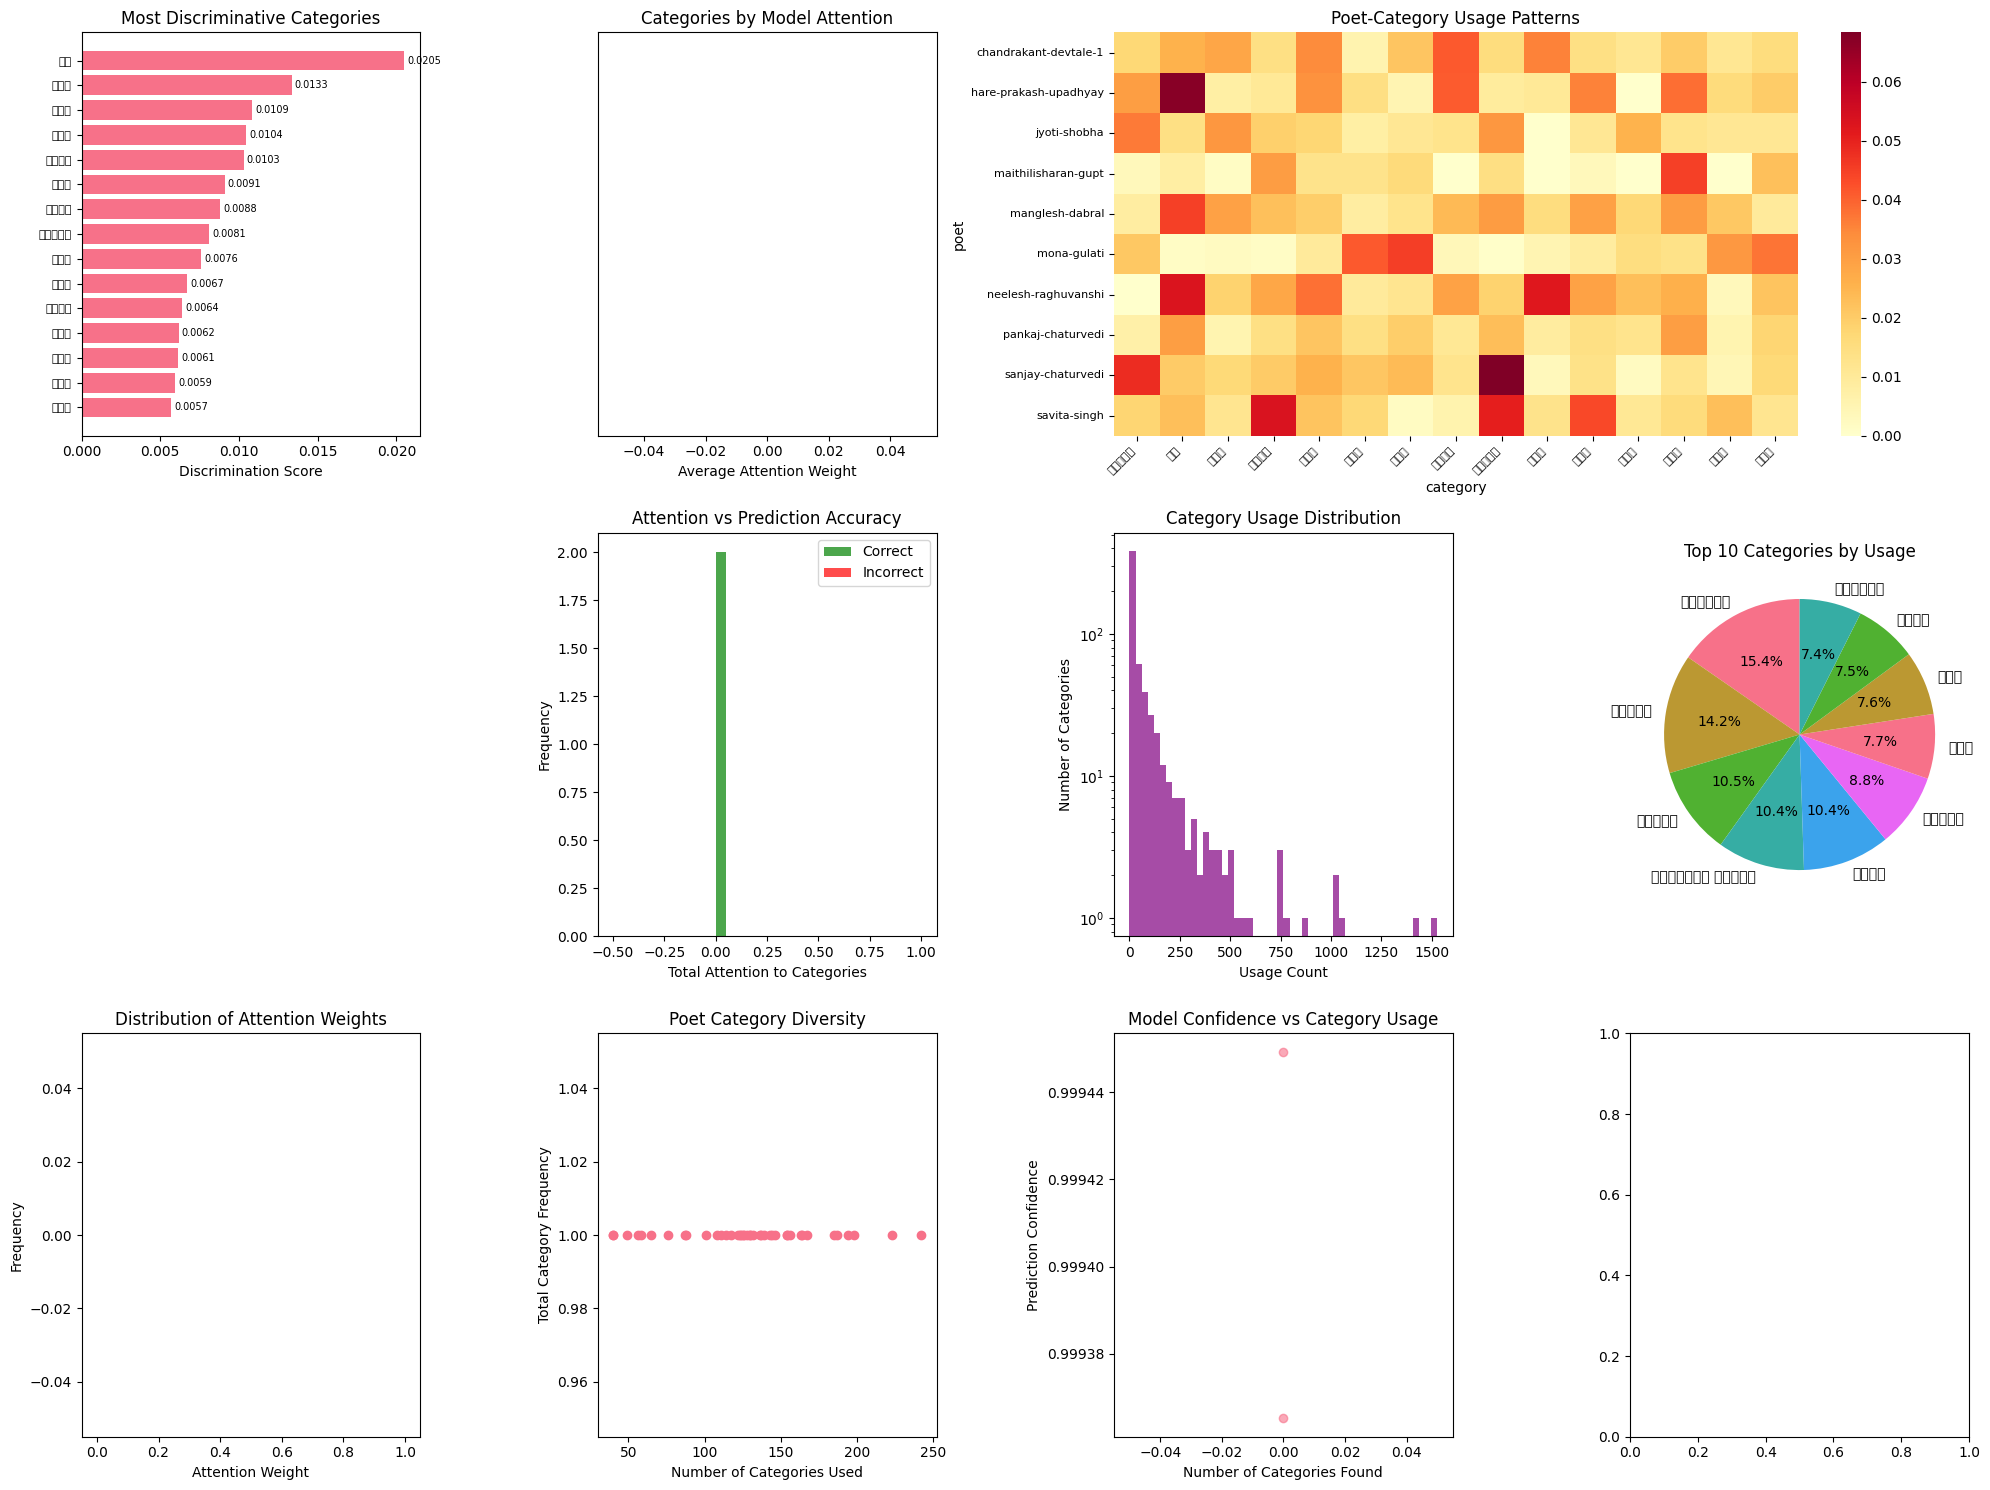


CATEGORY ANALYSIS SUMMARY
Total categories analyzed: 603
Categories found in poems: 478
Average categories per poem: 0.00
Poets analyzed: 41

KEY INSIGHTS:
1. Most discriminative category: घर
❌ Error during analysis: list index out of range
Please check that all required variables (model, tokenizer, etc.) are loaded.


In [21]:
# Cell 28 - Category-Based Model Interpretability Analysis
# Add this cell to your existing notebook

# First, run the category analysis
print("🔍 CATEGORY-BASED MODEL INTERPRETABILITY ANALYSIS")
print("=" * 80)

# Load the category analysis code (copy the CategoryAnalyzer class above)
# Then run the analysis:

try:
    # Run comprehensive category analysis
    category_results = run_category_analysis(
        model=model,
        tokenizer=tokenizer, 
        label_encoder=label_encoder,
        poems_df=df_filtered,
        cluster_labels=analysis_df['kmeans_cluster'].values if 'analysis_df' in locals() else None
    )
    
    print("\n✅ Category analysis completed successfully!")
    
    # Create visualizations
    print("\n📊 Creating visualizations...")
    visualize_category_analysis(category_results, df_filtered)
    
    # Create category embeddings visualization
    print("\n🎨 Creating category embeddings visualization...")
    create_category_embeddings_viz(category_results, df_filtered)
    
    # Save results for further analysis
    import pickle
    with open(f'{output_dir}/category_analysis_results.pkl', 'wb') as f:
        pickle.dump(category_results, f)
    print(f"💾 Results saved to: {output_dir}/category_analysis_results.pkl")
    
    print("\n🎯 ANALYSIS COMPLETE!")
    print("This analysis reveals:")
    print("1. Which thematic categories help the model distinguish poets")
    print("2. How the model pays attention to different category words")
    print("3. Category preferences of different poets")
    print("4. Relationship between category usage and prediction accuracy")
    print("5. Thematic clustering of poets based on category usage")
    
except FileNotFoundError:
    print("❌ Category file not found at /data/literature/category_counts.json")
    print("Please ensure the file exists and the path is correct.")
except Exception as e:
    print(f"❌ Error during analysis: {e}")
    print("Please check that all required variables (model, tokenizer, etc.) are loaded.")